In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
#Load dataset
df = pd.read_csv("/content/Jamboree_Admission_dataset.csv")
df.head()
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
#Cleaning column names
df.columns = df.columns.str.strip()
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

In [ ]:
#) Basic structure check
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics:\n", df.describe().T)

Shape: (500, 9)

Data types:
 Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

Missing values:
 Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

Duplicate rows: 0

Summary statistics:
                    count       mean         std     min       25%     50%  \
Serial No.         500.0  250.50000  144.481833    1.00  125.7500  250.50   
GRE Score          500.0  316.47200   11.295148  290.00  308.0000  317.00   
TOEFL Score        500.0  107.19200    6.081868   92.00  103.0000  107.00   
University Rating  500.0    3.11400    1.143512    1.00    2.0000    3.00   
SOP                500.0    3.3

In [ ]:
#Drop unique identifier
#Serial No. is just a row ID, so remove it.
#This is important because row numbers do not carry predictive meaning and can mislead the model.
df.drop("Serial No.", axis=1, inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
#Convert categorical variable Research is binary, so convert it to category for analysis clarity.
df["Research"] = df["Research"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          500 non-null    int64   
 1   TOEFL Score        500 non-null    int64   
 2   University Rating  500 non-null    int64   
 3   SOP                500 non-null    float64 
 4   LOR                500 non-null    float64 
 5   CGPA               500 non-null    float64 
 6   Research           500 non-null    category
 7   Chance of Admit    500 non-null    float64 
dtypes: category(1), float64(4), int64(3)
memory usage: 28.1 KB


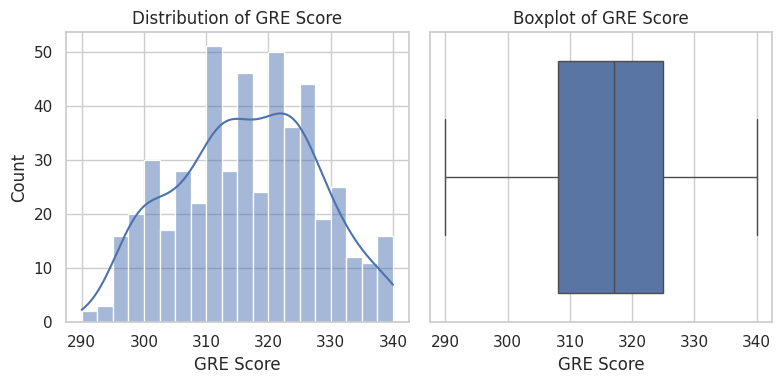

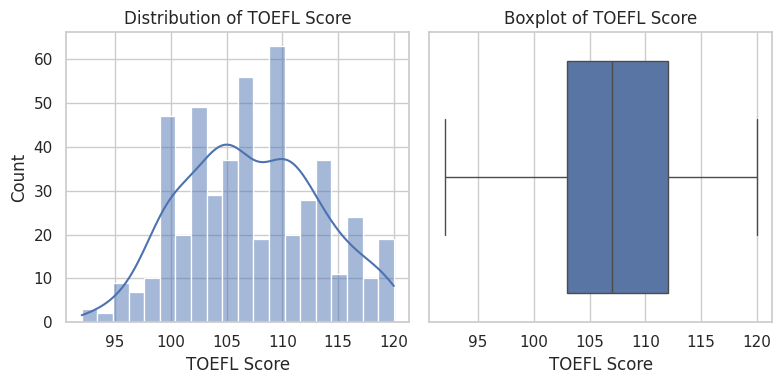

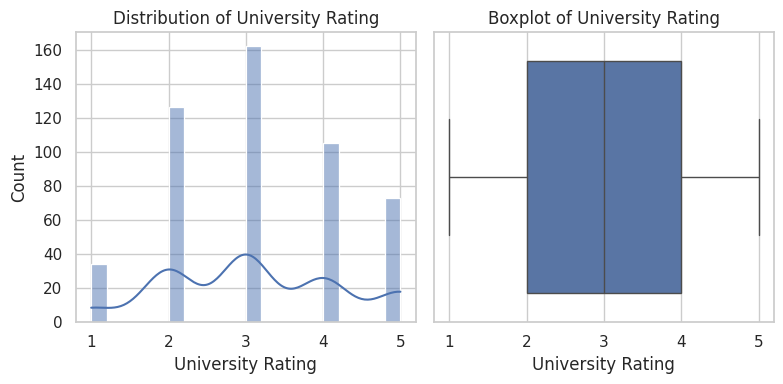

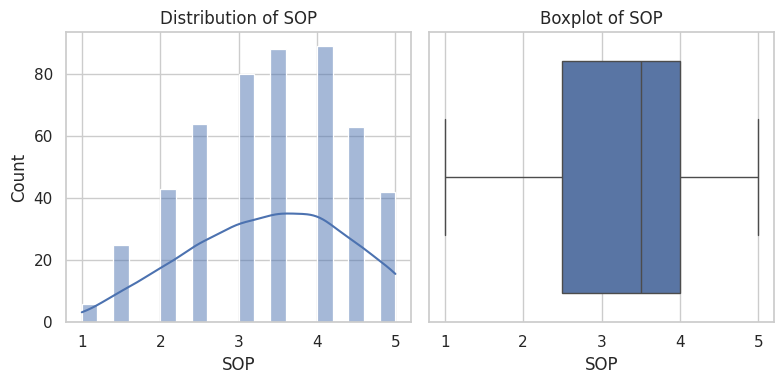

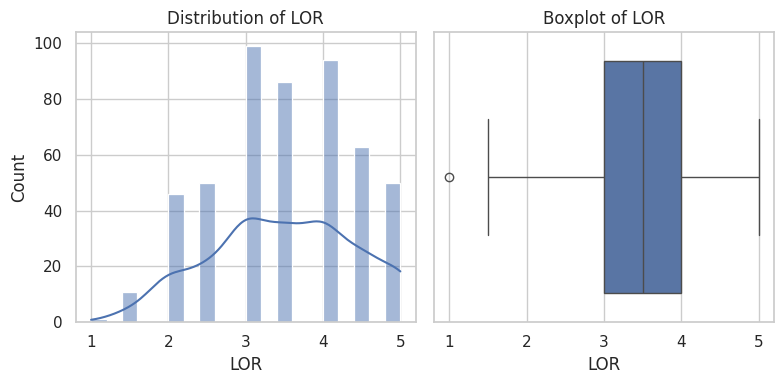

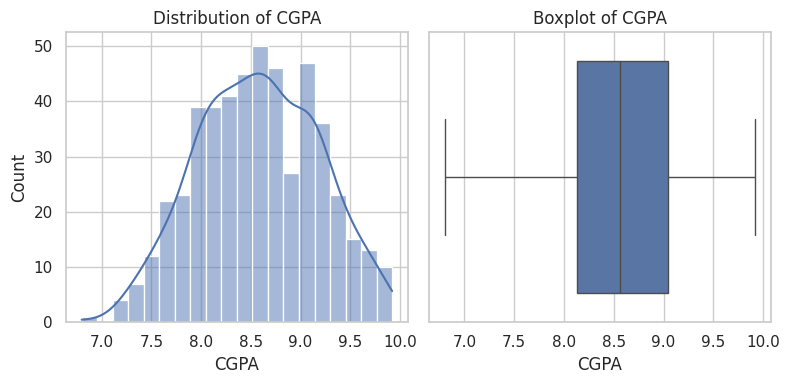

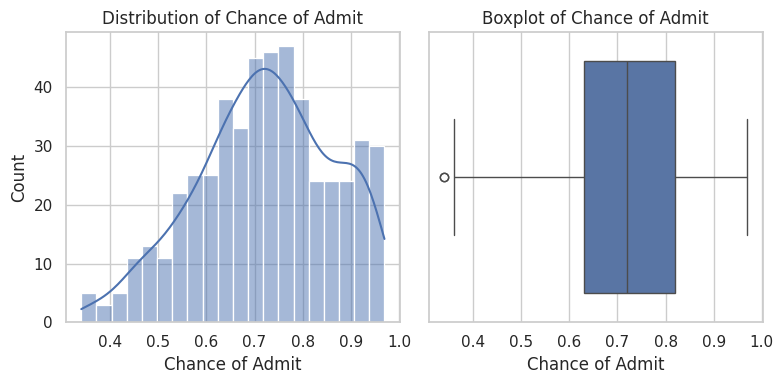

In [ ]:
#EDA
# Univariate analysis
#Continuous variables
cont_cols = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR", "CGPA", "Chance of Admit"]
for col in cont_cols:
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

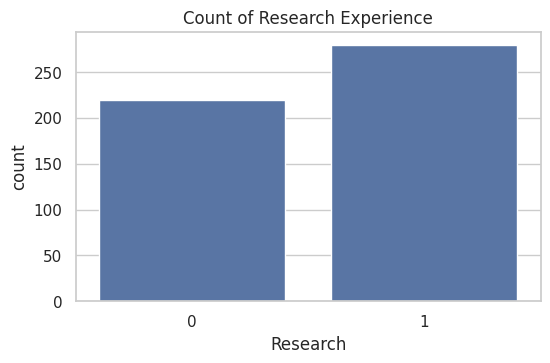

Research
1    280
0    220
Name: count, dtype: int64
Research
1    56.0
0    44.0
Name: proportion, dtype: float64


In [ ]:
#Categorical variable
plt.figure(figsize=(6,3.5))
sns.countplot(x="Research", data=df)
plt.title("Count of Research Experience")
plt.show()

print(df["Research"].value_counts())
print(df["Research"].value_counts(normalize=True)*100)

**INSIGHTS**


*	GRE, TOEFL, and CGPA are slightly concentrated toward the higher side, showing that many applicants in the dataset are academically strong.
* SOP, LOR, and University Rating mostly lie in the mid-to-high range, suggesting the dataset contains students with varied but generally decent academic profiles.
*   Research is a binary feature, and both categories are present, so it can be meaningfully used in modeling.
*   “Chance of Admit” appears fairly continuous and not extremely skewed, which is suitable for linear regression.

The observed score ranges suggest the dataset includes applicants with different merit levels, which is useful for understanding admission patterns.

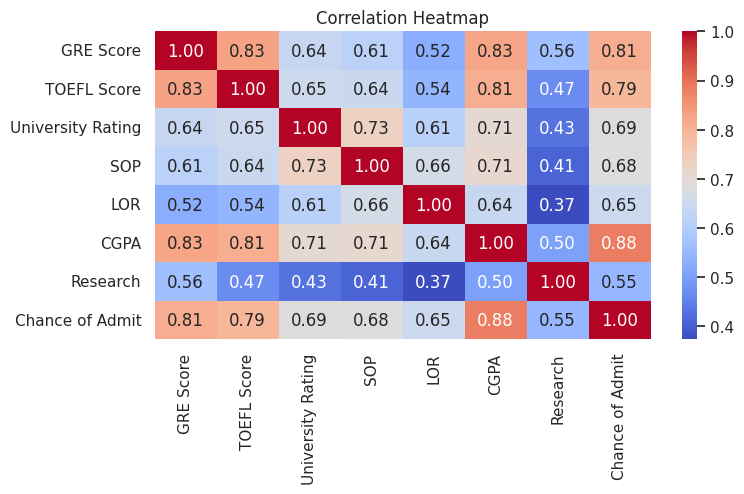

In [ ]:
#Bivariate analysis
# Correlation heatmap
df_corr = df.copy()
df_corr["Research"] = df_corr["Research"].astype(int)

plt.figure(figsize=(8,4))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

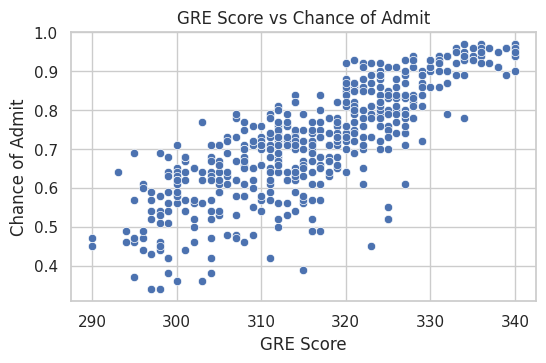

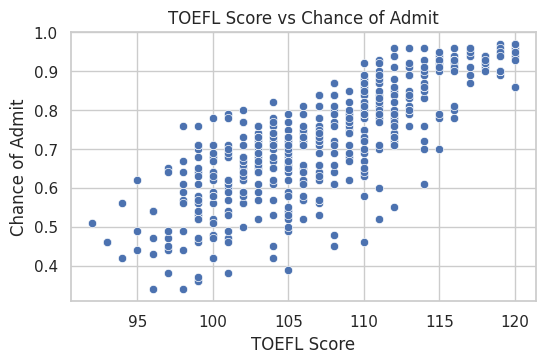

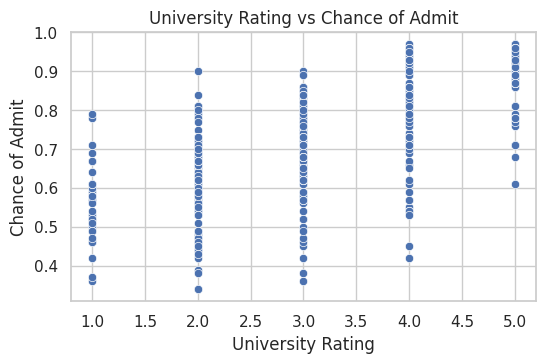

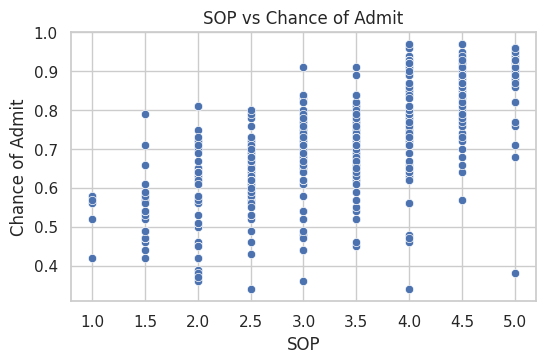

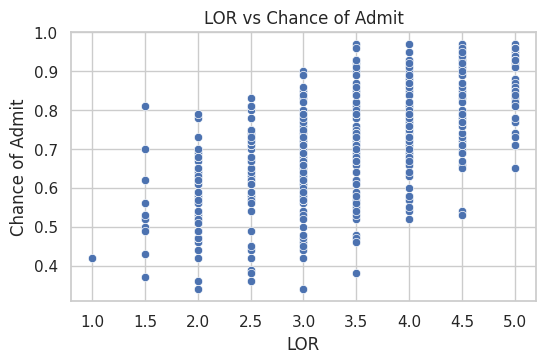

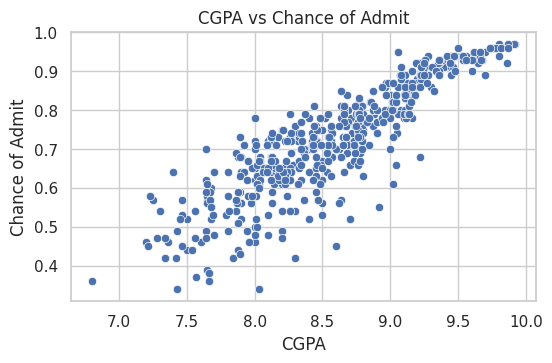

In [ ]:
#Pairplots / scatterplots with target
features = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR", "CGPA"]

for col in features:
    plt.figure(figsize=(6,3.5))
    sns.scatterplot(x=df[col], y=df["Chance of Admit"])
    plt.title(f"{col} vs Chance of Admit")
    plt.show()

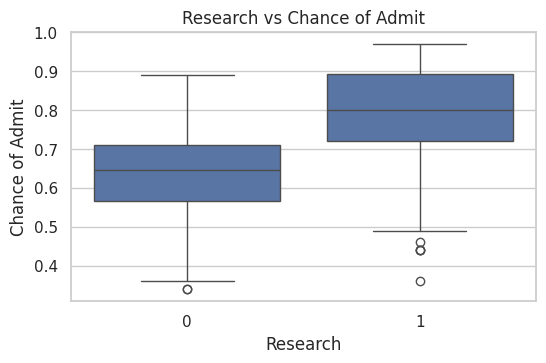

In [ ]:
#Research vs chance
plt.figure(figsize=(6,3.5))
sns.boxplot(x="Research", y="Chance of Admit", data=df)
plt.title("Research vs Chance of Admit")
plt.show()

**INSIGHTS**
* CGPA generally shows the strongest positive relationship with Chance of Admit.
* GRE and TOEFL also show positive associations, meaning stronger test scores tend to align with higher admission chances.
* SOP, LOR, and University Rating have moderate positive relationships with the target.
* Students with research experience tend to have a higher median chance of admission than those without research.

Independent variables such as GRE, TOEFL, and CGPA may also be correlated with one another, so multicollinearity must be checked before finalizing the model.

In [ ]:
#Data preprocessing
#Missing values and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64
Duplicates: 0


No missing-value treatment or duplicate treatment required.

In [ ]:
#Outlier check
for col in ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR", "CGPA", "Chance of Admit"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers")

GRE Score: 0 outliers
TOEFL Score: 0 outliers
University Rating: 0 outliers
SOP: 0 outliers
LOR: 1 outliers
CGPA: 0 outliers
Chance of Admit: 2 outliers


**INSIGHTS**
* No row identifier was kept in the model.
* Missing values and duplicates were checked before modeling.
* Outliers were inspected, but treatment should only be done if values are clearly unreasonable; in admissions data, extreme but valid scores may still be meaningful.
* Research was treated as categorical for interpretation and converted to numeric when needed for correlation/modeling.



**Model building**


In [ ]:
#Prepare X and y
df_model = df.copy()
df_model["Research"] = df_model["Research"].astype(int)

X = df_model.drop("Chance of Admit", axis=1)
y = df_model["Chance of Admit"]

In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Build linear regression using statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 24 May 2026   Prob (F-statistic):          3.41e-142
Time:                        15:22:38   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

In [ ]:
#Coefficients with feature names
coeff_df = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values,
    "p_value": model.pvalues.values
})
coeff_df

,Feature,Coefficient,p_value
0,const,-1.421447,9.326216e-27
1,GRE Score,0.002434,3.357625e-05
2,TOEFL Score,0.002996,1.619658e-03
3,University Rating,0.002569,5.414408e-01
4,SOP,0.001814,7.211636e-01
5,LOR,0.017238,1.947965e-04
6,CGPA,0.112527,1.086636e-22
7,Research,0.024027,1.337508e-03


**INSIGHTS**
* Check R^2 and Adjusted R^2 to understand explanatory power.
* Look at p-values to determine statistically significant predictors.
* Positive coefficients mean that as the variable increases, Chance of Admit tends to increase, holding other variables constant.
* Variables with high p-values may not contribute significantly once other variables are already in the model.

**Linear regression assumptions**

In [ ]:
#Multicollinearity using VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_df = calculate_vif(X_train)
vif_df

X_train_vif = X_train.copy()
X_test_vif = X_test.copy()

while True:
    vif = calculate_vif(X_train_vif)
    max_vif = vif["VIF"].max()
    if max_vif > 5:
        drop_col = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]
        print("Dropping:", drop_col, "| VIF:", max_vif)
        X_train_vif = X_train_vif.drop(columns=[drop_col])
        X_test_vif = X_test_vif.drop(columns=[drop_col])
    else:
        break

print(vif)
#refitting the model
X_train_sm2 = sm.add_constant(X_train_vif)
X_test_sm2 = sm.add_constant(X_test_vif)

model_vif = sm.OLS(y_train, X_train_sm2).fit()
print(model_vif.summary())

Dropping: GRE Score | VIF: 1284.0679013427632
Dropping: CGPA | VIF: 692.3524021887757
Dropping: SOP | VIF: 32.45409811453795
Dropping: LOR | VIF: 24.85002465010831
Dropping: University Rating | VIF: 11.883675381547858
       Feature       VIF
0  TOEFL Score  2.379543
1     Research  2.379543
                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     389.4
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.52e-94
Time:                        15:22:38   Log-Likelihood:                 434.91
No. Observations:                 400   AIC:                            -863.8
Df Residuals:                     397   BIC:                            -851.8
Df Model:                           2                                      

In [ ]:
#Mean of residuals
train_pred = model_vif.predict(X_train_sm2)
residuals = y_train - train_pred

print("Mean of residuals:", residuals.mean())

Mean of residuals: 4.804490139065365e-16


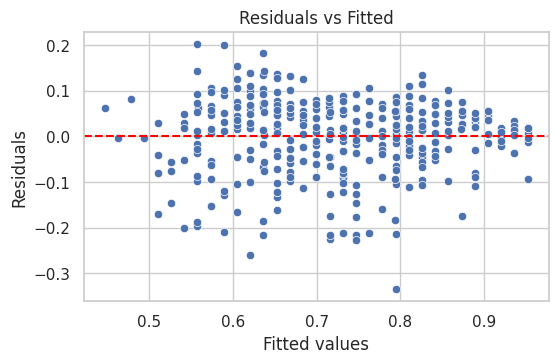

In [ ]:
#Linearity of variables
plt.figure(figsize=(6,3.5))
sns.scatterplot(x=train_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()
#Interpretation: if no clear curve or systematic pattern appears, linearity is reasonably satisfied.

In [ ]:
#Homoscedasticity test
bp_test = het_breuschpagan(residuals, X_train_sm2)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))
#p-value > 0.05, homoscedasticity can be assumed.

{'Lagrange multiplier statistic': np.float64(15.454587736040981), 'p-value': np.float64(0.00044063492139042226), 'f-value': np.float64(7.9775640737546505), 'f p-value': np.float64(0.00040104874603712323)}


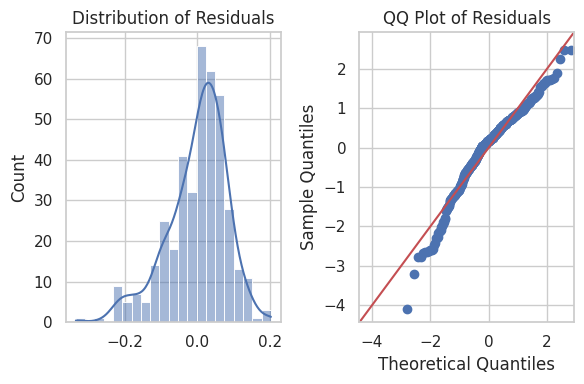

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9585672623108449), pvalue=np.float64(3.4777228441819287e-09))


In [ ]:
#Normality of residuals
plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")

plt.subplot(1,2,2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title("QQ Plot of Residuals")

plt.tight_layout()
plt.show()
shapiro_test = stats.shapiro(residuals)
print("Shapiro-Wilk Test:", shapiro_test)

**Model evaluation**

In [ ]:
#Train and test predictions
train_pred = model_vif.predict(X_train_sm2)
test_pred = model_vif.predict(X_test_sm2)
#Evaluation metrics
def regression_metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-n_features-1)
    return mae, rmse, r2, adj_r2

train_mae, train_rmse, train_r2, train_adj_r2 = regression_metrics(y_train, train_pred, X_train_vif.shape[1])
test_mae, test_rmse, test_r2, test_adj_r2 = regression_metrics(y_test, test_pred, X_test_vif.shape[1])

print("Train Metrics")
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("R2:", train_r2)
print("Adjusted R2:", train_adj_r2)

print("\nTest Metrics")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R2:", test_r2)
print("Adjusted R2:", test_adj_r2)

Train Metrics
MAE: 0.06282011177919433
RMSE: 0.08157672501409131
R2: 0.6623459813901373
Adjusted R2: 0.6606449535885763

Test Metrics
MAE: 0.06237185210161618
RMSE: 0.08043761005252416
R2: 0.6836083564321793
Adjusted R2: 0.6770848173895438


**INSIGHTS**


* If train and test scores are close, the model generalizes reasonably well.
* Lower MAE and RMSE indicate smaller prediction errors.
* Higher R^2 and Adjusted R^2 indicate better explanatory power.
* If test performance is much worse than train performance, the model may be overfitting.



In [ ]:
#Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

print("Ridge Train R2:", r2_score(y_train, ridge_train_pred))
print("Ridge Test R2:", r2_score(y_test, ridge_test_pred))
print("Ridge Test RMSE:", np.sqrt(mean_squared_error(y_test, ridge_test_pred)))

Ridge Train R2: 0.8210631423824621
Ridge Test R2: 0.8187885396675396
Ridge Test RMSE: 0.06087507177653933


In [ ]:
#Lasso model
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

print("Lasso Train R2:", r2_score(y_train, lasso_train_pred))
print("Lasso Test R2:", r2_score(y_test, lasso_test_pred))
print("Lasso Test RMSE:", np.sqrt(mean_squared_error(y_test, lasso_test_pred)))

Lasso Train R2: 0.8209829096830558
Lasso Test R2: 0.8191828243130252
Lasso Test RMSE: 0.06080880892435433


In [ ]:
#Coefficients of Ridge and Lasso
ridge_coef = pd.DataFrame({
    "Feature": X.columns,
    "Ridge_Coefficient": ridge.coef_
})

lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Lasso_Coefficient": lasso.coef_
})

print(ridge_coef)
print(lasso_coef)

             Feature  Ridge_Coefficient
0          GRE Score           0.026789
1        TOEFL Score           0.018355
2  University Rating           0.003046
3                SOP           0.001937
4                LOR           0.015893
5               CGPA           0.067011
6           Research           0.011949
             Feature  Lasso_Coefficient
0          GRE Score           0.026612
1        TOEFL Score           0.017919
2  University Rating           0.002746
3                SOP           0.001592
4                LOR           0.015392
5               CGPA           0.067734
6           Research           0.011360


**Key findings**

•	CGPA is usually the most influential predictor of admission chance, followed by GRE and TOEFL.

•	Research experience tends to improve admission probability.

•	SOP, LOR, and University Rating also matter, though their contribution may become smaller when stronger academic variables are already present.

•	Some predictors are correlated with each other, so checking VIF is necessary before trusting coefficients.


**Assumptions summary**

•	Mean of residuals should be close to zero.

•	Residual vs fitted plot should show no visible pattern.

•	Breusch–Pagan p-value above 0.05 suggests homoscedasticity.

•	Residual histogram and QQ plot should show approximate normality.

•	VIF values below 5 indicate acceptable multicollinearity.


**Actionable recommendations**


1.	Jamboree should emphasize CGPA, GRE, and TOEFL as major levers in its admission predictor because these variables are likely to have the strongest relationship with admit chance.
2.	Students with low predicted probability should receive targeted guidance such as improving test scores, strengthening SOP/LOR quality, or gaining research exposure.
3.	The current model is useful as a directional estimator, but it should not be presented as a guaranteed decision tool because real admissions involve uncertainty and university-specific preferences.
4.	Jamboree can improve prediction quality by collecting more features such as undergraduate college quality, work experience, internship quality, research publications, intended program, and university-specific admit history.
5.	In production, the output should be shown as a probability range or band instead of a single exact value to communicate uncertainty more responsibly.


**Project conclusion**

This project analyzed the factors affecting graduate admission chances and developed a linear regression model to predict admission probability. The analysis shows that academic strength variables such as CGPA, GRE Score, and TOEFL Score are key drivers of admission outcomes, while profile-enhancing variables like research experience, SOP, and LOR also play an important role. After validating the core assumptions of linear regression and comparing regularized models such as Ridge and Lasso, the model can be considered a useful baseline tool for Jamboree’s website feature, with scope for further improvement using richer applicant and university-level data.
